# **Modelagem de Tótpicos**

## 1. Bibliotecas

In [1]:
# BIBLIOTECAS
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
import re

## 2. Extração dos dados

In [2]:
# EXTRAÇÃO
df = pd.read_excel(
    "../input/artigos_start.xls",
    sheet_name="Papers",
    skiprows=7 #pular linhas
)
df = df[["Year", "Authors", "Title", "Keywords", "Abstract"]]
df.head()

,Year,Authors,Title,Keywords,Abstract
0,2002,"Bolton, RJ and Hand, DJ",Statistical fraud detection: A review,fraud detection; fraud prevention; statistics;...,Fraud is increasing dramatically with the expa...
1,2009,"Sanver, Mert and Karahoca, Adem",Fraud Detection Using an Adaptive Neuro-Fuzzy ...,GSM Fraud; Fraud Detection; Data mining; ANFIS...,GSM (Global Services of Mobile Communications)...
2,2012,"Olszewski, Dominik",Employing Kullback-Leibler divergence and Late...,Kullback-Leibler divergence; mixture models; L...,"In this paper, a method for telecommunications..."
3,2012,"Olszewski, Dominik",A probabilistic approach to fraud detection in...,Kullback-Leibler divergence; Latent Dirichlet ...,"In this paper, a method for telecommunications..."
4,2025,"Cam, Nguyen Tan and Hiep, Dinh Hoai",Fraud calls detection using class-imbalanced l...,Class-imbalanced learning; Generative adversar...,The rapid growth of mobile networks has enhanc...


## 3. Análise e exploração dos dados (AED)

TOTAL DE ARTIGOS : 202


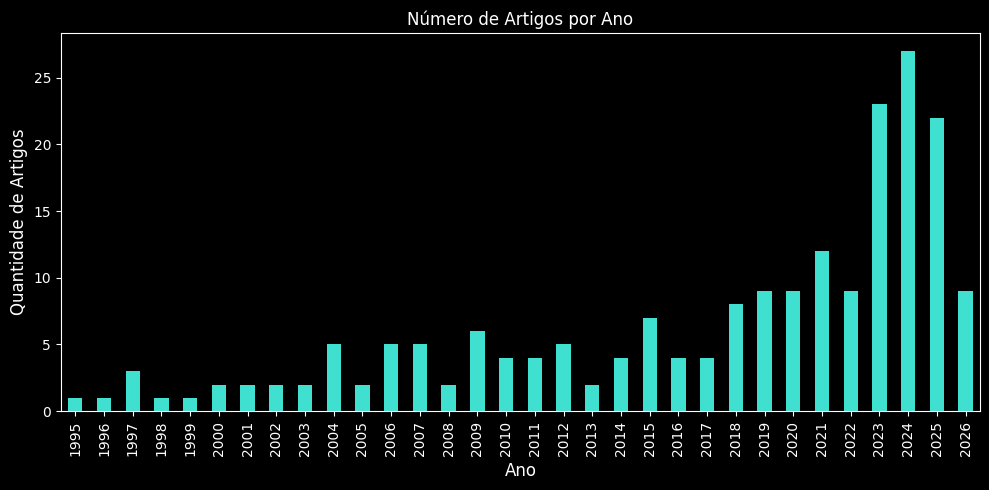

NUVEM DE PALAVRAS | TITLE


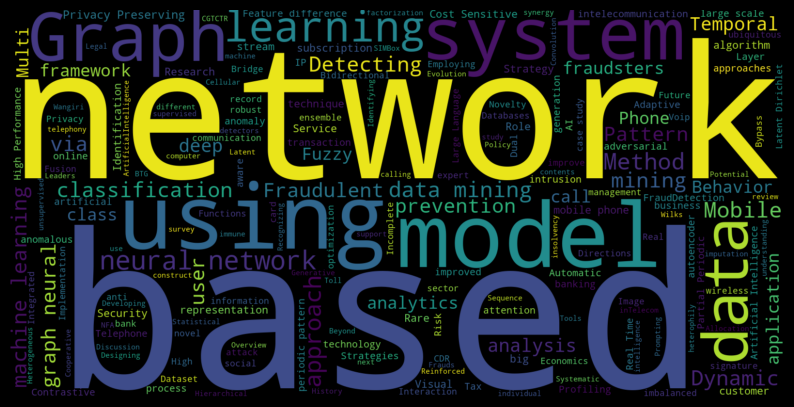

NUVEM DE PALAVRAS | KEYWORDS


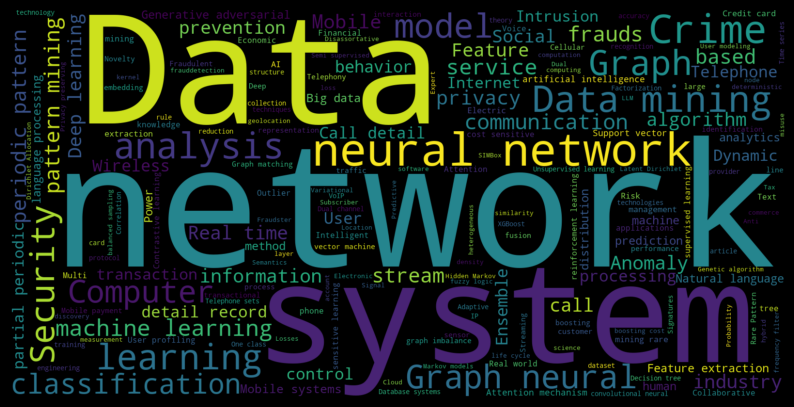

NUVEM DE PALAVRAS | ABSTRACT


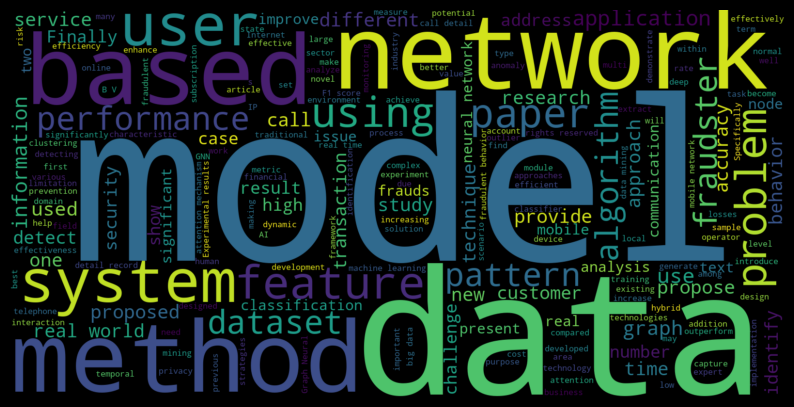

In [3]:
# TOTAL DE ARTIGOS
total_artigos = df.shape[0]
print(f"TOTAL DE ARTIGOS : {total_artigos}")

# ARTIGOS POR ANO
artigos_por_ano = df['Year'].value_counts().sort_index()
artigos_por_ano.plot(kind='bar', figsize=(10,5), color='turquoise')
plt.title('Número de Artigos por Ano', fontsize = 12)
plt.xlabel('Ano', fontsize = 12)
plt.ylabel('Quantidade de Artigos', fontsize = 12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# NUVEM DE PALAVRAS
def gerar_nuvem_palavras(coluna):
    
    nome_coluna = coluna.name.lower()
    textos = " ".join(coluna.dropna().astype(str)) #Concatena os textos
    
    stopwords = set(STOPWORDS)
    # Stopwords personalizadas (Palavras-chave de pessquisa no WoS e Scopus)
    stopwords.update(["fraud", "detection"])
    textos = re.sub(r'\btelecom\w*', '', textos, flags=re.IGNORECASE) # Que iniciem com "telecom*""

    wordcloud = WordCloud(stopwords=stopwords,
                        background_color="black",
                        width=1600,
                        height=800).generate(textos)

    print(f"NUVEM DE PALAVRAS | {nome_coluna.upper()}")

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

    wordcloud.to_file(f"../output/nuvem_{nome_coluna}.png")

gerar_nuvem_palavras(coluna=df["Title"])
gerar_nuvem_palavras(coluna=df["Keywords"])
gerar_nuvem_palavras(coluna=df["Abstract"])


## 4. Preparação dos dados

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
          return ""
    text = re.sub(r'\s+', ' ', text)                      #espaços duplicados
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)            #remove símbolos não ASCII
    text = re.sub(r'[^\w\s.,]', '', text)                 #remove símbolos especiais
    return text.strip()

# Combina os textos dos título e do resumo do artigo
texto_limpo = df['Title'].str.strip() + '. ' + df['Abstract'].str.strip()
texto_limpo = texto_limpo.str.lower()
texto_limpo = texto_limpo.apply(clean_text)
texto_limpo.head()

0    statistical fraud detection a review. fraud is...
1    fraud detection using an adaptive neurofuzzy i...
2    employing kullbackleibler divergence and laten...
3    a probabilistic approach to fraud detection in...
4    fraud calls detection using classimbalanced le...
dtype: str

## 5. Modelagem

### 5.1 BERTopic